 ================================================================================================================================================================================================

 NOTEBOOK 04 — ZHU GUARDED LWC RETRIEVAL (CLEANED)

 ================================================================================================================================================================================================



 Pipeline: load data -> 30 s time-average DWR -> dDWR/dH diagnostic ->

 Zhu **guarded** retrieval -> LWC quality checks -> LWP (3 checks only, for later comparison)



 Removed in this cleanup (all still recoverable from notebook history if needed):

   - 60 s time-averaging branch

   - Raw / un-averaged Zhu retrieval exploration (superseded by the 30 s branch, which is

     what feeds the guarded retrieval anyway)

   - Most LWP diagnostics — kept only: general LWP time series, LWP closure scatter,

     and the "spot check three profiles" comparison

   - 500-1500 m windowed retrieval experiment

   - common_mask (C1/C2) redundant second retrieval pass

 ================================================================================================================================================================================================

 ## 0. Setup

In [1]:
from pathlib import Path

retrieval_dir = Path("../src/radar_lwc/retrieval").resolve()
print(retrieval_dir)
print(list(retrieval_dir.glob("*.py")))


C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval
[WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/average_ze_time.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/ddwr_dh.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/dielectric.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/dq_retrieval.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/gas_attenuation.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/kappa_liquid.py'), WindowsPath('C:/Projects/Masterarbeit/dual_freq_radar_lwc/src/radar_lwc/retrieval/zhu.py')]


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(str(Path("../src").resolve()))

# Preprocessing
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity

# Retrieval
from radar_lwc.retrieval.average_ze_time import avg_ze_time
from radar_lwc.retrieval.ddwr_dh import compute_ddwr_dh
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.kappa_liquid import kappa_liquid


In [18]:
in_path = Path("../data/processed/retrieval_input_2km_alpha_kappa_calculated.nc")
ds_retrieval = xr.open_dataset(in_path)
print(ds_retrieval)


<xarray.Dataset> Size: 40MB
Dimensions:        (Time: 10441, range: 74)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    TAlt           (range) float32 296B ...
    HAlt           (range) float32 296B ...
Data variables: (12/14)
    Ze_W           (Time, range) float32 3MB ...
    Ze_Ka          (Time, range) float32 3MB ...
    T_cloud        (Time, range) float32 3MB ...
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 3MB ...
    cloud_mask     (Time, range) bool 773kB ...
    ...             ...
    alpha_W        (Time, range) float64 6MB ...
    alpha_Ka       (Time, range) float64 6MB ...
    kappa_W        (Time, range) float32 3MB ...
    kappa_Ka       (Time, range) float32 3MB ...
    MeanVel_W      (Time, range) float32 3MB ...
    MeanVel_Ka     (Time, range) float32 3MB ...
Attributes:
    description:  Prepared in

 ================================================================================================================================================================================================

 ## 1. Time averaging (30 s only)



 Averaging Ze in linear space before forming DWR beats down per-gate DWR noise, which is a

 prerequisite for a physically meaningful dDWR/dH gradient. 30 s was kept as the working

 resolution; 60 s is dropped for now (barely changed the diagnostics — restore quickly by

 copying the `window_s=60` block back in if a comparison is ever needed again).

 ================================================================================================================================================================================================

In [19]:
ze_ka_avg = avg_ze_time(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)), window_s=30)
ze_w_avg  = avg_ze_time(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)),  window_s=30)

dwr_2km_smoothed = ze_ka_avg - ze_w_avg
dwr_2km_smoothed.name = "DWR"


In [34]:
# %% 1 dB gate-to-gate filter (Socuellamos): replace spikes by linear interpolation
gate_threshold = 1.0  # dB

def despike_1d(dwr_1d, threshold=1.0):
    """
    dwr_1d: 1D array along range for a single time step.
    A gate i is an outlier if it differs from BOTH neighbours by more than
    `threshold` dB in the same direction (i.e. it's a spike relative to a
    smooth profile) -> replaced by linear interpolation between i-1 and i+1.
    """
    out = dwr_1d.copy()
    n = len(dwr_1d)
    for i in range(1, n - 1):
        left = dwr_1d[i] - dwr_1d[i - 1]
        right = dwr_1d[i] - dwr_1d[i + 1]
        is_spike = (
            np.abs(left) > threshold
            and np.abs(right) > threshold
            and np.sign(left) == np.sign(right)   # same direction on both sides
        )
        if is_spike and not (np.isnan(dwr_1d[i - 1]) or np.isnan(dwr_1d[i + 1]) or np.isnan(dwr_1d[i])):
            out[i] = dwr_1d[i - 1] + (dwr_1d[i + 1] - dwr_1d[i - 1]) * 0.5  # linear interp
    return out

dwr_2km_filt = xr.apply_ufunc(
    despike_1d,
    dwr_2km_smoothed,
    input_core_dims=[["range"]],
    output_core_dims=[["range"]],
    kwargs={"threshold": gate_threshold},
    vectorize=True,
)
dwr_2km_filt.name = "DWR"
dwr_2km_filt.attrs = dwr_2km_smoothed.attrs

n_replaced = int((np.abs(dwr_2km_filt - dwr_2km_smoothed) > 1e-9).sum())
print(f"Gates replaced by interpolation: {n_replaced} "
      f"({n_replaced / dwr_2km_smoothed.size:.2%} of all gates)")

Gates replaced by interpolation: 58605 (7.59% of all gates)


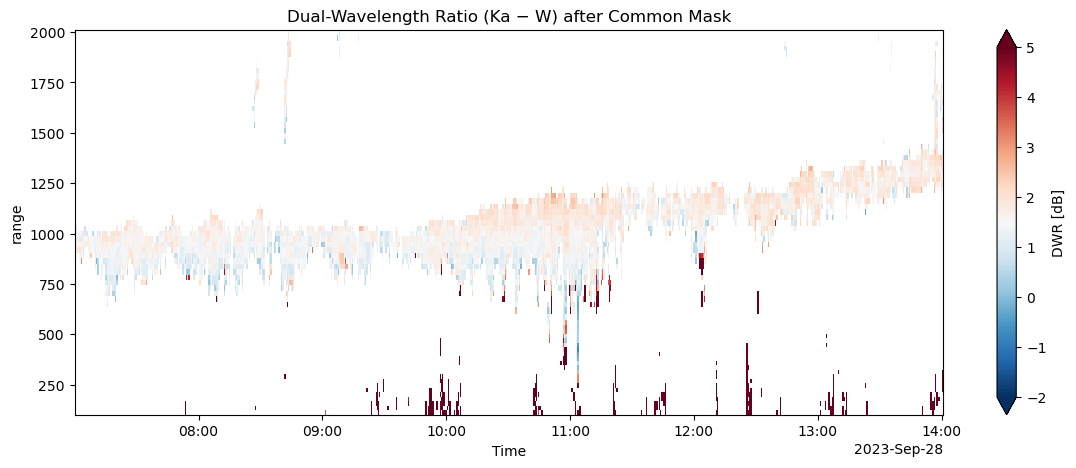

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km_filt.where(ds_retrieval["common_mask"]).plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio (Ka − W) after Common Mask")
plt.show()

 ## 2. dDWR/dH diagnostic (30 s smoothed input)



 This is the key sanity check before trusting the gradient-based retrieval: how much of the

 in-cloud gradient is still noise (negative or unphysically large |dDWR/dH|)?

In [36]:
ddwr_dh_smoothed = compute_ddwr_dh(dwr_2km_filt, ds_retrieval["cloud_mask"], N_default=9)

vals = ddwr_dh_smoothed.where(ds_retrieval["cloud_mask"]).values.ravel()
vals = vals[np.isfinite(vals)]
print("After 30 s time-averaging:")
print(f"  Fraction dDWR/dh < 0:          {(vals < 0).mean():.2%}")
print(f"  Fraction |dDWR/dh| > 30 dB/km: {(np.abs(vals) > 30).mean():.2%}")
print(f"  median dDWR/dh:                {np.median(vals):.2f} dB/km")


After 30 s time-averaging:
  Fraction dDWR/dh < 0:          31.94%
  Fraction |dDWR/dh| > 30 dB/km: 3.39%
  median dDWR/dh:                1.91 dB/km


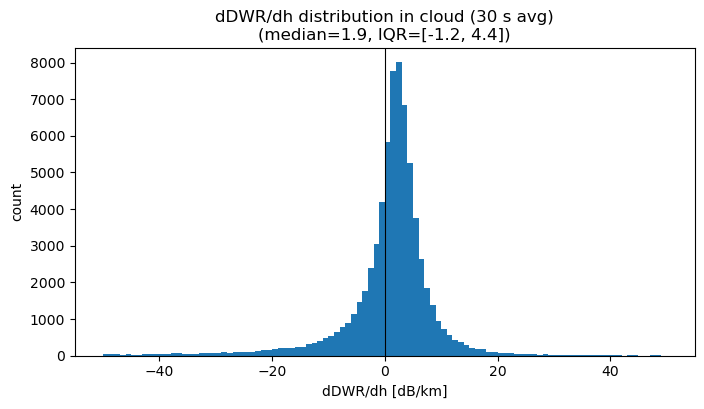

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vals, bins=100, range=(-50, 50))
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("dDWR/dh [dB/km]")
ax.set_ylabel("count")
ax.set_title(f"dDWR/dh distribution in cloud (30 s avg)\n"
             f"(median={np.median(vals):.1f}, "
             f"IQR=[{np.percentile(vals,25):.1f}, {np.percentile(vals,75):.1f}])")
plt.show()


 (Supporting context for the guard thresholds below — per-gate DWR noise estimate from

 vertical-neighbour differences.)

In [ ]:
D = dwr_2km_filt.where(ds_retrieval["common_mask"]).values                 #Filtered DWR values where the common mask is True
diffs = D[:, 1:] - D[:, :-1]                                  # DWR(i+1)−DWR(i)   Subtracting the DWR value of the next gate from the current gate to get the difference between adjacent gates
diffs = diffs[np.isfinite(diffs)]               # Remove NaN
noise_estimate = np.std(diffs) / np.sqrt(2)      #standard deviation of the difference tells how widely these differences scatter. Signal is supposed to be the same in neighbouring gates, so difference should be zero. Rest is just noise. The Variance Difference is Var(Ni+1​−Ni​)= Var(Ni+1​)+Var(Ni​) = σ^2+σ^2 =2σ^2.Therefore: Std(Ni+1​−Ni​)=sqrt(2)*σ Finally: noise = std_difference / np.sqrt(2)
print(f"Estimated per-gate DWR noise: {noise_estimate:.2f} dB")
print(f"Median in-cloud DWR:          {float(dwr_2km_filt.where(ds_retrieval['common_mask']).median()):.2f} dB")
print(f"Signal across a 9-gate (~200 m) window at 5 dB/km: {5 * 0.20:.2f} dB")    # Comparison Noise and Signal across  Window


Estimated per-gate DWR noise: 0.51 dB
Median in-cloud DWR:          1.64 dB
Signal across a 9-gate (~200 m) window at 5 dB/km: 1.00 dB


 ================================================================================================================================================================================================

 ## 3. Zhu Guarded retrieval



 Drop-in replacement for the plain gradient retrieval: overlap-averages the window fit and

 rejects windows that are too noisy (`max_window_std`) or produce an unphysical gradient

 (`max_ddwr_dh`), with `edge_pad` gates skipped near cloud base/top.

 ================================================================================================================================================================================================

In [39]:
def retrieve_lwc_zhu_guarded(
    dwr, kappa_w, kappa_ka, alpha_w, alpha_ka, common_mask,
    N_default=9,
    max_ddwr_dh=50.0,      # dB/km — physical ceiling on |dDWR/dh|
    max_window_std=3.0,    # dB    — reject noisy windows
    edge_pad=1,            # skip edge gates near cloud base/top
):
    """
    Zhu-style LWC retrieval with overlap averaging + sanity guards.
    Assumes dims ('Time', 'range'). Returns (LWC g/m^3, n_windows per gate).
    """
    h = dwr["range"].values.astype(float)
    D = dwr.values
    Kw, Kka = kappa_w.values, kappa_ka.values
    Aw, Aka = alpha_w.values, alpha_ka.values
    M = common_mask.values
    nt, nr = D.shape

    lwc_sum = np.zeros_like(D)
    lwc_cnt = np.zeros_like(D)

    for t in range(nt):
        cloud_idx = np.flatnonzero(M[t])
        if cloud_idx.size < 3:
            continue
        i0 = cloud_idx.min() + edge_pad
        i1 = cloud_idx.max() - edge_pad
        if i1 - i0 + 1 < 3:
            continue
        Nt = min(N_default, i1 - i0 + 1)

        for i in range(i0, i1 - Nt + 2):
            sl = slice(i, i + Nt)
            if not M[t, sl].all():
                continue
            dwin = D[t, sl]
            if not np.isfinite(dwin).all():
                continue
            if dwin.std() > max_window_std:
                continue
            a, b, _c = np.polyfit(h[sl], dwin, 2)
            grad = (2 * a * h[sl] + b) * 1000.0   # dB/km
            if np.any(np.abs(grad) > max_ddwr_dh):
                continue
            dkappa = Kw[t, sl] - Kka[t, sl]
            dalpha = Aw[t, sl] - Aka[t, sl]
            with np.errstate(divide="ignore", invalid="ignore"):
                lwc_win = (0.5 * grad - dalpha) / dkappa
            lwc_sum[t, sl] += lwc_win
            lwc_cnt[t, sl] += 1

    with np.errstate(invalid="ignore", divide="ignore"):
        lwc = np.where(lwc_cnt > 0, lwc_sum / lwc_cnt, np.nan)

    lwc_da = xr.DataArray(
        lwc, coords=dwr.coords, dims=dwr.dims, name="lwc",
        attrs={"units": "g m-3", "long_name": "LWC (Zhu 2019, guarded)"},
    )
    n_da = xr.DataArray(lwc_cnt, coords=dwr.coords, dims=dwr.dims, name="n_windows")
    return lwc_da, n_da


lwc_guarded, n_windows = retrieve_lwc_zhu_guarded(
    dwr=dwr_2km_filt,
    kappa_w=ds_retrieval["kappa_W"],
    kappa_ka=ds_retrieval["kappa_Ka"],
    alpha_w=ds_retrieval["alpha_W"],
    alpha_ka=ds_retrieval["alpha_Ka"],
    common_mask=ds_retrieval["common_mask"],
    N_default=9,
)

print(f"Gates with any retrieval: {int((n_windows > 0).sum())} "
      f"({100*float((n_windows>0).mean()):.1f}%)")
print(f"Mean windows per gate:    {float(n_windows.where(n_windows>0).mean()):.1f}")


Gates with any retrieval: 61573 (8.0%)
Mean windows per gate:    2.3


 ================================================================================================================================================================================================

 ## 4. LWC quality checks (kept: LWC<0, LWC maps, dDWR/dH already above, + 2 supporting graphs)

 ================================================================================================================================================================================================

 ### 4a. LWC < 0

In [43]:
print(f"Fraction LWC < 0: "
      f"{float((lwc_guarded < 0).sum() / lwc_guarded.notnull().sum()):.2%}")
print(f"LWC quantiles: "
      f"p05={float(lwc_guarded.quantile(0.05)):.2f}, "
      f"p50={float(lwc_guarded.quantile(0.5)):.2f}, "
      f"p95={float(lwc_guarded.quantile(0.95)):.2f} g/m^3")


Fraction LWC < 0: 34.82%
LWC quantiles: p05=-1.61, p50=0.20, p95=1.38 g/m^3


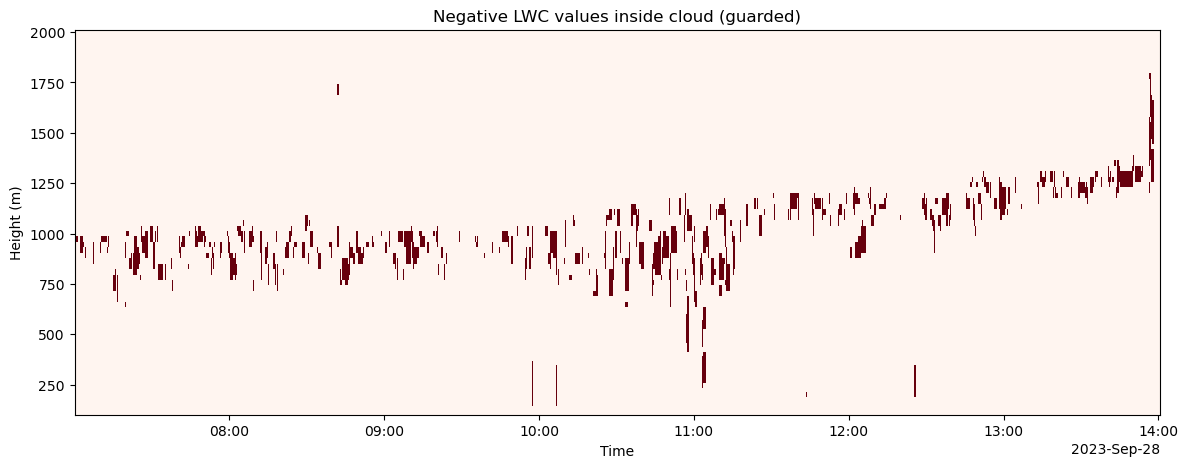

In [42]:
negative_lwc = (lwc_guarded < 0) & ds_retrieval["common_mask"]

plt.figure(figsize=(14, 5))
negative_lwc.astype(int).plot(x="Time", y="range", cmap="Reds", add_colorbar=False)
plt.title("Negative LWC values inside cloud (guarded)")
plt.xlabel("Time"); plt.ylabel("Height (m)")
plt.show()


 ### 4b. LWC map (main output)

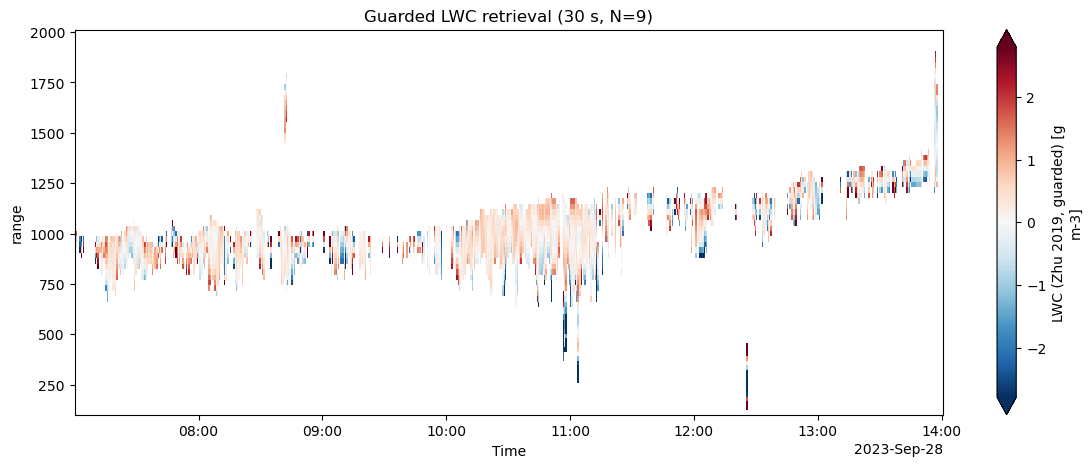

In [54]:
lwc_guarded.plot(
    x="Time", y="range", figsize=(14, 5), cmap="RdBu_r", robust=True,
)
plt.title("Guarded LWC retrieval (30 s, N=9)")
plt.show()


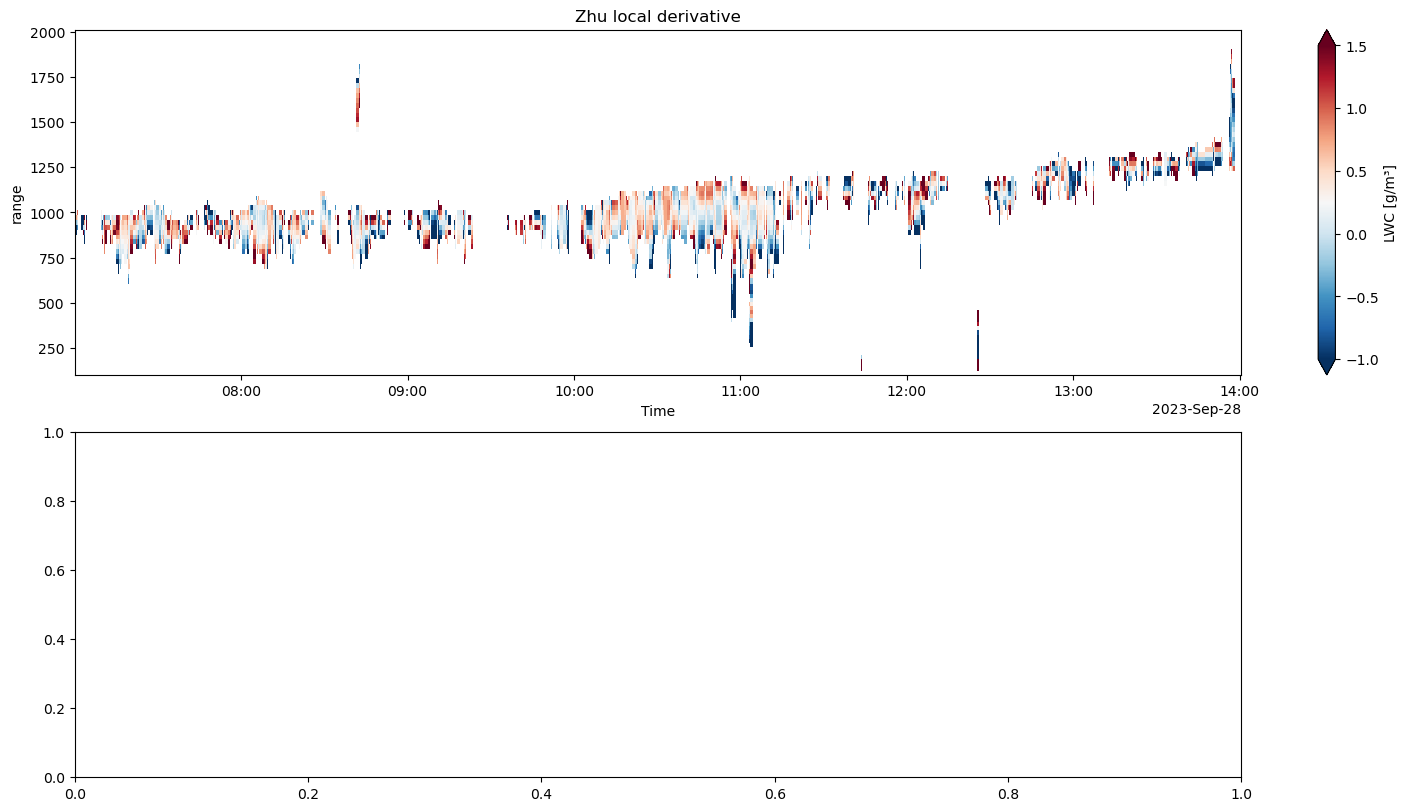

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
lwc_guarded.where(ds_retrieval["common_mask"]).plot(
    x="Time", y="range", ax=axes[0], vmin=-1, vmax=1.5, cmap="RdBu_r",
    cbar_kwargs={"label": "LWC [g/m³]"})
axes[0].set_title("Zhu local derivative")

plt.show()

 ### 4c. Two supporting graphs: LWC distribution + negative-gradient locations

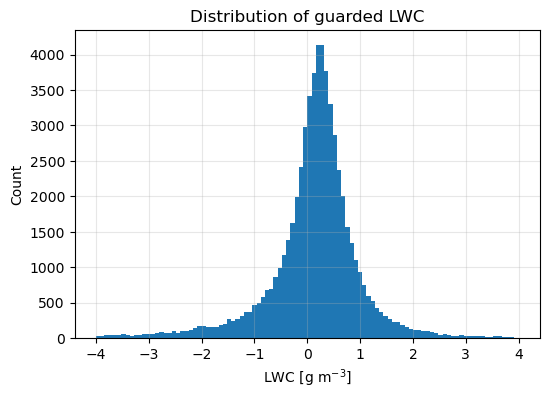

In [45]:
vals = lwc_guarded.where(ds_retrieval["common_mask"]).values
vals = vals[np.isfinite(vals)]

plt.figure(figsize=(6, 4))
plt.hist(vals, bins=100, range=(-4, 4))
plt.xlabel("LWC [g m$^{-3}$]")
plt.ylabel("Count")
plt.title("Distribution of guarded LWC")
plt.grid(alpha=0.3)
plt.show()


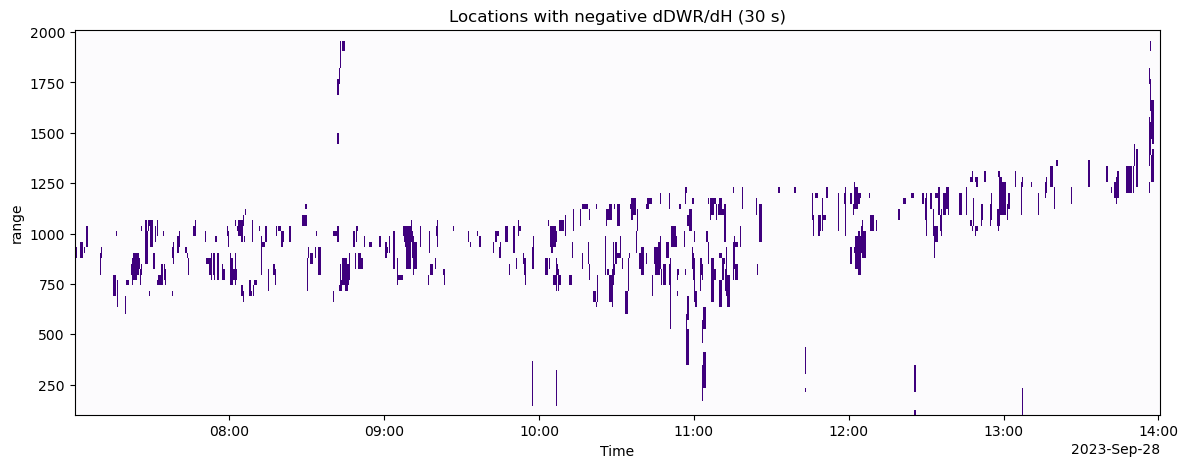

In [46]:
negative_grad = (ddwr_dh_smoothed < 0) & ds_retrieval["common_mask"]

plt.figure(figsize=(14, 5))
negative_grad.astype(int).plot(x="Time", y="range", cmap="Purples", add_colorbar=False)
plt.title("Locations with negative dDWR/dH (30 s)")
plt.show()


 ================================================================================================================================================================================================

 ## 5. LWP — kept only for later comparison (general chart, closure scatter, 3-profile spot check)

 ================================================================================================================================================================================================

 ### 5a. General LWP chart

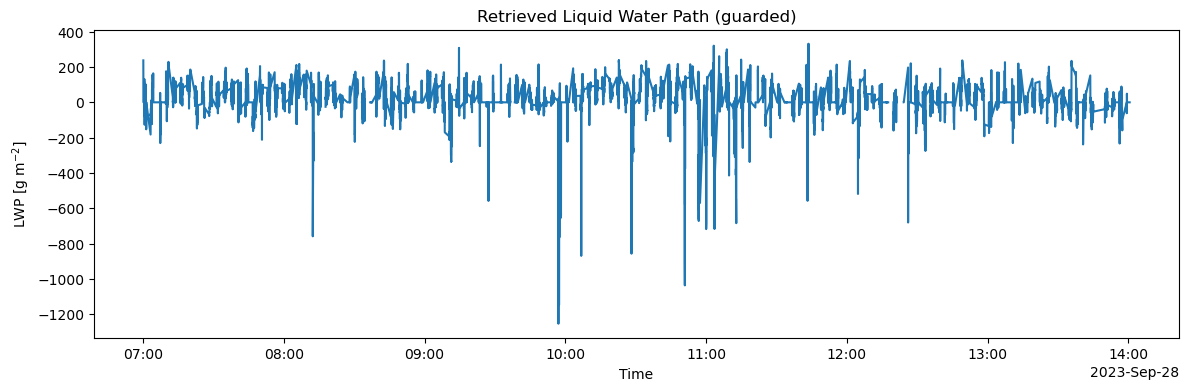

In [61]:
dz = float(dwr_2km_filt["range"].sel(range=slice(0, 2000)).diff("range").mean())
lwp_guarded = (lwc_guarded.where(ds_retrieval["common_mask"]).fillna(0) * dz).sum(dim="range")
lwp_guarded = lwp_guarded.where(ds_retrieval["common_mask"].any(dim="range"))
lwp_guarded.attrs["units"] = "g m-2"

fig, ax = plt.subplots(figsize=(14, 4))
lwp_guarded.plot(ax=ax)
ax.set_title("Retrieved Liquid Water Path (guarded)")
ax.set_ylabel("LWP [g m$^{-2}$]")
ax.set_xlabel("Time")
plt.show()


 ### 5b. LWP closure test (scatter vs MWR)

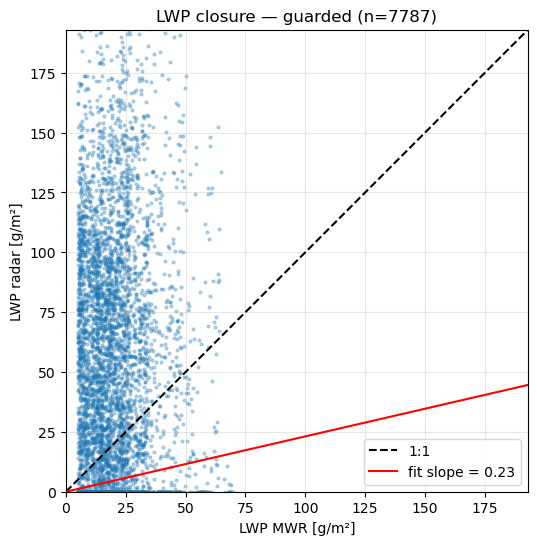

Slope through origin: 0.23   (want ~1.0)
Correlation:          -0.11   (want > 0.7)
Bias:  radar - MWR = -6.8 g/m²


In [48]:
x = ds_retrieval["LWP"].values
y = lwp_guarded.values
good = np.isfinite(x) & np.isfinite(y) & (x > 5)   # ignore near-zero MWR

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[good], y[good], s=4, alpha=0.3)
lim = max(np.nanpercentile(x[good], 99), np.nanpercentile(y[good], 99))
ax.plot([0, lim], [0, lim], "k--", label="1:1")
slope = np.nansum(x[good] * y[good]) / np.nansum(x[good] ** 2)
ax.plot([0, lim], [0, slope * lim], "r-", label=f"fit slope = {slope:.2f}")
ax.set_xlabel("LWP MWR [g/m²]"); ax.set_ylabel("LWP radar [g/m²]")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(f"LWP closure — guarded (n={good.sum()})")
plt.show()

corr = np.corrcoef(x[good], y[good])[0, 1]
print(f"Slope through origin: {slope:.2f}   (want ~1.0)")
print(f"Correlation:          {corr:.2f}   (want > 0.7)")
print(f"Bias:  radar - MWR = {np.nanmean(y[good] - x[good]):+.1f} g/m²")


 ### 5c. Spot-check three profiles (kept for later comparison across methods)

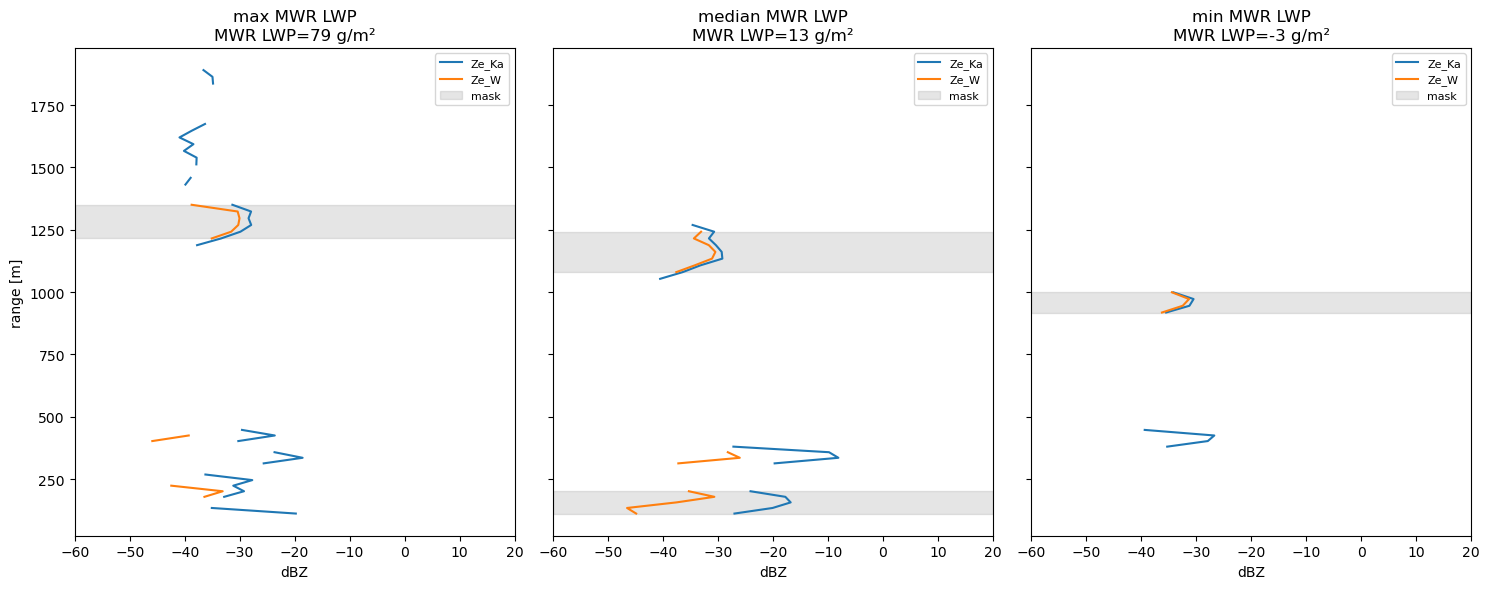

In [58]:
lwp_mwr_vals = ds_retrieval["LWP"].values
i_hi   = int(np.nanargmax(lwp_mwr_vals))
i_lo   = int(np.nanargmin(np.abs(lwp_mwr_vals - np.nanmedian(lwp_mwr_vals))))
i_zero = int(np.nanargmin(lwp_mwr_vals))

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, idx, label in zip(axes, [i_hi, i_lo, i_zero],
                          ["max MWR LWP", "median MWR LWP", "min MWR LWP"]):
    h = dwr_2km_smoothed["range"].values
    ax.plot(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)).isel(Time=idx), h, label="Ze_Ka")
    ax.plot(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)).isel(Time=idx),  h, label="Ze_W")
    mask_here = ds_retrieval["common_mask"].isel(Time=idx)
    ax.fill_betweenx(h, -60, 20, where=mask_here, color="grey", alpha=0.2, label="mask")
    ax.set_xlim(-60, 20); ax.set_xlabel("dBZ")
    ax.set_title(f"{label}\nMWR LWP={lwp_mwr_vals[idx]:.0f} g/m²")
    ax.legend(fontsize=8)
axes[0].set_ylabel("range [m]")
plt.tight_layout()
plt.show()


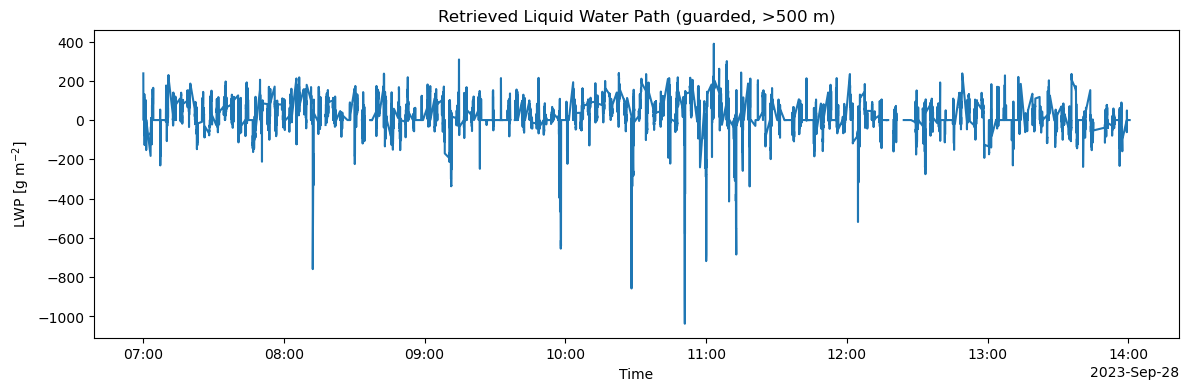

In [59]:
dz = float(dwr_2km_filt["range"].diff("range").mean())

retrieval_mask = ds_retrieval["common_mask"] & (ds_retrieval["range"] >= 500)

lwp_guarded = (
    lwc_guarded.where(retrieval_mask)
    .fillna(0)
    * dz
).sum(dim="range")

lwp_guarded = lwp_guarded.where(retrieval_mask.any(dim="range"))
lwp_guarded.attrs["units"] = "g m-2"

fig, ax = plt.subplots(figsize=(14, 4))
lwp_guarded.plot(ax=ax)
ax.set_title("Retrieved Liquid Water Path (guarded, >500 m)")
ax.set_ylabel("LWP [g m$^{-2}$]")
ax.set_xlabel("Time")
plt.show()

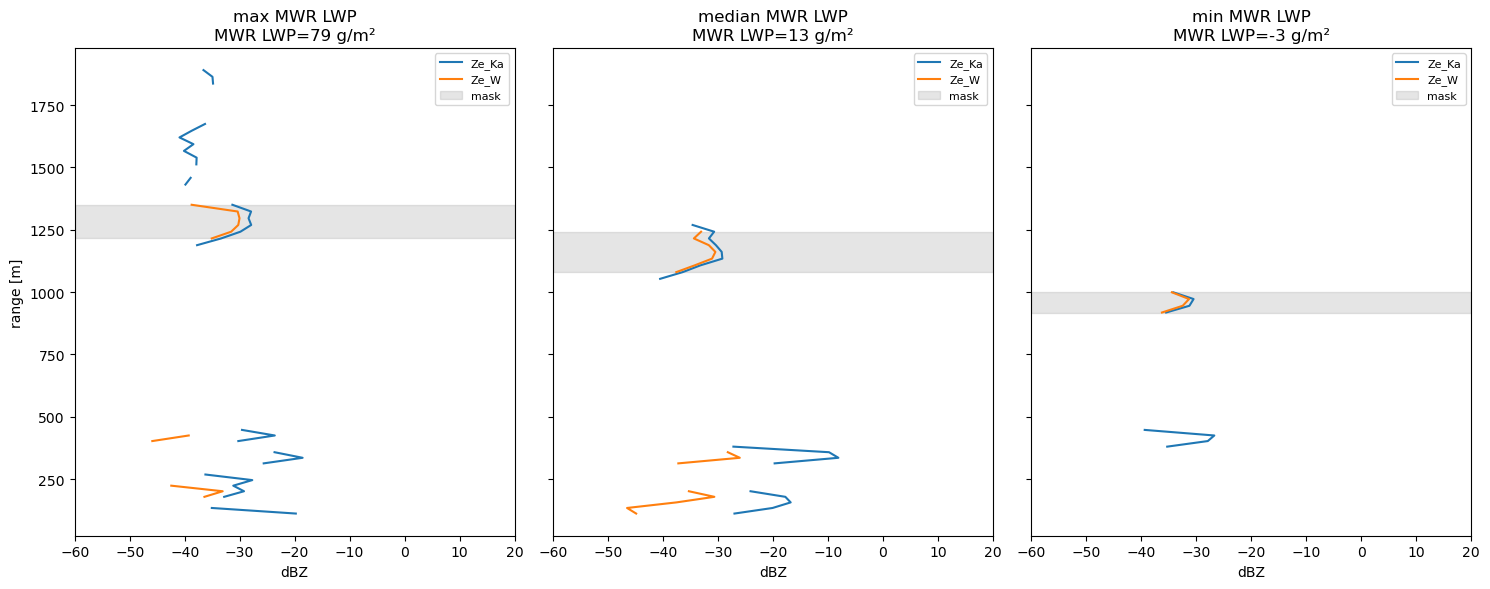

In [60]:
retrieval_mask = ds_retrieval["common_mask"] & (ds_retrieval["range"] >= 500)

lwp_mwr_vals = ds_retrieval["LWP"].values
i_hi   = int(np.nanargmax(lwp_mwr_vals))
i_lo   = int(np.nanargmin(np.abs(lwp_mwr_vals - np.nanmedian(lwp_mwr_vals))))
i_zero = int(np.nanargmin(lwp_mwr_vals))

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, idx, label in zip(
    axes,
    [i_hi, i_lo, i_zero],
    ["max MWR LWP", "median MWR LWP", "min MWR LWP"],
):
    h = dwr_2km_smoothed["range"].values

    ax.plot(ds_retrieval["Ze_Ka"].sel(range=slice(0, 2000)).isel(Time=idx), h, label="Ze_Ka")
    ax.plot(ds_retrieval["Ze_W"].sel(range=slice(0, 2000)).isel(Time=idx), h, label="Ze_W")

    mask_here = retrieval_mask.isel(Time=idx)

    ax.fill_betweenx(
        h, -60, 20,
        where=mask_here,
        color="grey",
        alpha=0.2,
        label="mask"
    )

    ax.set_xlim(-60, 20)
    ax.set_xlabel("dBZ")
    ax.set_title(f"{label}\nMWR LWP={lwp_mwr_vals[idx]:.0f} g/m²")
    ax.legend(fontsize=8)

axes[0].set_ylabel("range [m]")
plt.tight_layout()
plt.show()